In [1]:
import sys
print(sys.version)
print(sys.executable)

3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
C:\Users\mynet\miniconda3\envs\timesfm\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import timesfm
print("✅ Kütüphaneler yüklendi")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.


C:\Users\mynet\miniconda3\envs\timesfm\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded PyTorch TimesFM, likely because python version is 3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)].
✅ Kütüphaneler yüklendi
NumPy: 2.2.6
Pandas: 2.3.3


In [3]:
# ============================================================
# İSTANBUL 39 İLÇE SU TÜKETİM TAHMİNİ - TimesFM
# Konut ve işyeri ayrı ayrı tahmin edilir, sonra toplanır
# Eğitim: 2020-01 → 2024-12  |  Tahmin: 2025-01 → 2025-12
# ============================================================
# ── AŞAMA 1: KÜTÜPHANELERİ İÇE AKTAR ──────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# TimesFM kurulum komutu (ilk çalıştırmadan önce terminalde çalıştır):
# pip install timesfm
import timesfm

print("✅ Kütüphaneler yüklendi")

✅ Kütüphaneler yüklendi


In [4]:
# ── AŞAMA 2: DOSYA YOLLARI ─────────────────────────────────
ABONE_DOSYA    = r"C:\Users\mynet\OneDrive\Masaüstü\Bitirme Projesi\Veriler\abone.xlsx"
SU_DOSYA       = r"C:\Users\mynet\OneDrive\Masaüstü\Bitirme Projesi\Veriler\su_tuketim.xlsx"
SICAKLIK_DOSYA = r"C:\Users\mynet\OneDrive\Masaüstü\Bitirme Projesi\Veriler\sicaklik.xlsx"

In [5]:
# ── AŞAMA 3: YARDIMCI FONKSİYON - TARİH PARSE ─────────────
AYLAR_TR = {
    "Ocak":1, "Şubat":2, "Mart":3, "Nisan":4,
    "Mayıs":5, "Haziran":6, "Temmuz":7, "Ağustos":8,
    "Eylül":9, "Ekim":10, "Kasım":11, "Aralık":12
}

def tarih_parse(tarih_str):
    parcalar = str(tarih_str).strip().split()
    yil = int(parcalar[0])
    ay  = AYLAR_TR[parcalar[-1]]
    return pd.Timestamp(year=yil, month=ay, day=1)

In [6]:
# ── AŞAMA 4: ABONE VERİSİNİ YÜKLE ──────────────────────────
abone_raw = pd.read_excel(ABONE_DOSYA, header=1)

konut = abone_raw.iloc[:, 0:3].copy()
konut.columns = ["ilce", "tarih", "konut_abone"]

isyeri = abone_raw.iloc[:, 8:11].copy()
isyeri.columns = ["ilce", "tarih", "isyeri_abone"]

konut  = konut.dropna(subset=["ilce", "tarih"]).reset_index(drop=True)
isyeri = isyeri.dropna(subset=["ilce", "tarih"]).reset_index(drop=True)

konut["tarih"]  = konut["tarih"].apply(tarih_parse)
isyeri["tarih"] = isyeri["tarih"].apply(tarih_parse)

abone_df = pd.merge(konut, isyeri, on=["ilce", "tarih"], how="outer")
abone_df = abone_df[["ilce", "tarih", "konut_abone", "isyeri_abone"]]

print(f"✅ Abone verisi: {abone_df.shape[0]} satır, {abone_df['ilce'].nunique()} ilçe")

✅ Abone verisi: 2808 satır, 39 ilçe


In [7]:
# ── AŞAMA 5: SU TÜKETİM VERİSİNİ YÜKLE ────────────────────
su_raw = pd.read_excel(SU_DOSYA, header=1)

konut_su = su_raw.iloc[:, 0:3].copy()
konut_su.columns = ["ilce", "tarih", "konut_m3"]

isyeri_su = su_raw.iloc[:, 4:7].copy()
isyeri_su.columns = ["ilce", "tarih", "isyeri_m3"]

konut_su  = konut_su.dropna(subset=["ilce", "tarih"]).reset_index(drop=True)
isyeri_su = isyeri_su.dropna(subset=["ilce", "tarih"]).reset_index(drop=True)

konut_su["tarih"]  = konut_su["tarih"].apply(tarih_parse)
isyeri_su["tarih"] = isyeri_su["tarih"].apply(tarih_parse)

konut_su["konut_m3"]   = pd.to_numeric(konut_su["konut_m3"],   errors="coerce")
isyeri_su["isyeri_m3"] = pd.to_numeric(isyeri_su["isyeri_m3"], errors="coerce")

su_df = pd.merge(konut_su, isyeri_su, on=["ilce", "tarih"], how="outer")
su_df = su_df[["ilce", "tarih", "konut_m3", "isyeri_m3"]]

print(f"✅ Su tüketim verisi: {su_df.shape[0]} satır, {su_df['ilce'].nunique()} ilçe")

✅ Su tüketim verisi: 2808 satır, 39 ilçe


In [8]:
# ── AŞAMA 6: SICAKLIK VERİSİNİ YÜKLE ───────────────────────
# header=1 → 2. satırı başlık olarak oku (ilk satır boş)
sicaklik_raw = pd.read_excel(SICAKLIK_DOSYA, header=1)

sicaklik_df = sicaklik_raw.rename(columns={
    "İLÇE": "ilce",
    "TARİH": "tarih",
    "ORTALAMA SICAKLIK": "sicaklik_c"
})

# "2020   Ocak" → datetime
tarih_split = sicaklik_df["tarih"].astype(str).str.strip().str.split(r"\s+", expand=True)
sicaklik_df["tarih"] = pd.to_datetime(
    tarih_split[0] + "-" + tarih_split[1].map(AYLAR_TR).astype(str),
    format="%Y-%m"
)

sicaklik_df["sicaklik_c"] = (
    sicaklik_df["sicaklik_c"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

sicaklik_df["ilce"] = sicaklik_df["ilce"].str.upper().str.strip()

print(f"✅ Sıcaklık verisi: {sicaklik_df.shape[0]} satır, {sicaklik_df['ilce'].nunique()} ilçe")

✅ Sıcaklık verisi: 2808 satır, 39 ilçe


In [9]:
# ── AŞAMA 7: İLÇE İSİMLERİNİ EŞLEŞTİR ─────────────────────
#eşleşmeyen ilçeler
ilce_su       = set(su_df["ilce"].str.upper().str.strip().unique())
ilce_abone    = set(abone_df["ilce"].str.upper().str.strip().unique())
ilce_sicaklik = set(sicaklik_df["ilce"].unique())

print(f"Su verisi      : {len(ilce_su)} ilçe")
print(f"Abone verisi   : {len(ilce_abone)} ilçe")
print(f"Sıcaklık verisi: {len(ilce_sicaklik)} ilçe")

print("\n── Su ∩ Abone ──────────────────────────────")
print("🔴 Abonede olup suda OLMAYAN  :", ilce_abone - ilce_su)
print("🔵 Suda olup abonede OLMAYAN  :", ilce_su - ilce_abone)

print("\n── Su ∩ Sıcaklık ───────────────────────────")
print("🔴 Sıcaklıkta olup suda OLMAYAN  :", ilce_sicaklik - ilce_su)
print("🔵 Suda olup sıcaklıkta OLMAYAN  :", ilce_su - ilce_sicaklik)

print("\n── Üç sette birden olan ilçe sayısı ────────")
print("✅", len(ilce_su & ilce_abone & ilce_sicaklik), "ilçe tam eşleşiyor")

print("\n── Üç setten herhangi birinde eksik olanlar ─")
tum_ilceler = ilce_su | ilce_abone | ilce_sicaklik
eksik = {i: [] for i in tum_ilceler}
for i in tum_ilceler:
    if i not in ilce_su:       eksik[i].append("su yok")
    if i not in ilce_abone:    eksik[i].append("abone yok")
    if i not in ilce_sicaklik: eksik[i].append("sıcaklık yok")
eksik = {k: v for k, v in eksik.items() if v}
for ilce, sorun in sorted(eksik.items()):
    print(f"  {ilce:25s} → {', '.join(sorun)}")

Su verisi      : 39 ilçe
Abone verisi   : 39 ilçe
Sıcaklık verisi: 39 ilçe

── Su ∩ Abone ──────────────────────────────
🔴 Abonede olup suda OLMAYAN  : set()
🔵 Suda olup abonede OLMAYAN  : set()

── Su ∩ Sıcaklık ───────────────────────────
🔴 Sıcaklıkta olup suda OLMAYAN  : set()
🔵 Suda olup sıcaklıkta OLMAYAN  : set()

── Üç sette birden olan ilçe sayısı ────────
✅ 39 ilçe tam eşleşiyor

── Üç setten herhangi birinde eksik olanlar ─


In [10]:
# Aşama 7 sonrası doğrulama
ilce_su       = set(su_df["ilce"].str.upper().str.strip().unique())
ilce_sicaklik = set(sicaklik_df["ilce"].unique())
eksik = ilce_sicaklik - ilce_su
if eksik:
    print(f"⚠️  Hâlâ eşleşmeyen {len(eksik)} ilçe var: {eksik}")
else:
    print("✅ Tüm 39 ilçe eşleşiyor, devam edilebilir")

✅ Tüm 39 ilçe eşleşiyor, devam edilebilir


In [11]:
# ── AŞAMA 8: ÜÇ VERİYİ BİRLEŞTİR ──────────────────────────
df = (
    su_df
    .merge(abone_df,    on=["ilce", "tarih"], how="inner")
    .merge(sicaklik_df, on=["ilce", "tarih"], how="inner")
)

df = df[["ilce", "tarih",
         "konut_m3", "isyeri_m3",
         "konut_abone", "isyeri_abone",
         "sicaklik_c"]]

df["yil"] = df["tarih"].dt.year
df["ay"]  = df["tarih"].dt.month

print(f"✅ Birleşik veri: {df.shape[0]} satır, {df['ilce'].nunique()} ilçe")
print(f"📅 Tarih aralığı: {df['tarih'].min().strftime('%Y-%m')} → {df['tarih'].max().strftime('%Y-%m')}")

✅ Birleşik veri: 2808 satır, 39 ilçe
📅 Tarih aralığı: 2020-01 → 2025-12


In [12]:
# ── AŞAMA 9: KEŞİFÇİ ANALİZ ────────────────────────────────
print("\n📊 GENEL İSTATİSTİKLER")
df["su_tuketimi_m3"] = df["konut_m3"] + df["isyeri_m3"]
print(df[["su_tuketimi_m3", "konut_m3", "isyeri_m3", "sicaklik_c"]].describe().round(2))

ilce_ort = df.groupby("ilce")["su_tuketimi_m3"].mean().sort_values(ascending=False)
print("\n🏆 EN ÇOK TÜKETİM (aylık ortalama m³):")
print(ilce_ort.head(5).apply(lambda x: f"{x:,.0f}").to_string())

yillik = df.groupby("yil")["su_tuketimi_m3"].sum()
print("\n📅 YILLIK TOPLAM TÜKETİM:")
print(yillik.apply(lambda x: f"{x:,.0f}").to_string())


📊 GENEL İSTATİSTİKLER
       su_tuketimi_m3    konut_m3   isyeri_m3  sicaklik_c
count         2808.00     2808.00     2808.00     2808.00
mean       1916492.43  1475069.18   441423.25       16.14
std         915371.40   724748.78   297589.20        6.72
min          22357.00    16817.00     2948.00        3.24
25%        1324871.75   958896.25   246765.50       10.13
50%        1842157.50  1428302.00   392879.50       15.77
75%        2362685.75  1872815.00   583546.00       22.51
max        6613796.00  4609887.00  5189876.00       28.28

🏆 EN ÇOK TÜKETİM (aylık ortalama m³):
ilce
ESENYURT     4,693,414
K.ÇEKMECE    3,327,449
PENDİK       3,286,926
ÜMRANİYE     3,191,811
BAĞCILAR     3,051,400

📅 YILLIK TOPLAM TÜKETİM:
yil
2020    857,292,555
2021    842,827,358
2022    901,007,924
2023    911,272,787
2024    944,775,278
2025    924,334,837


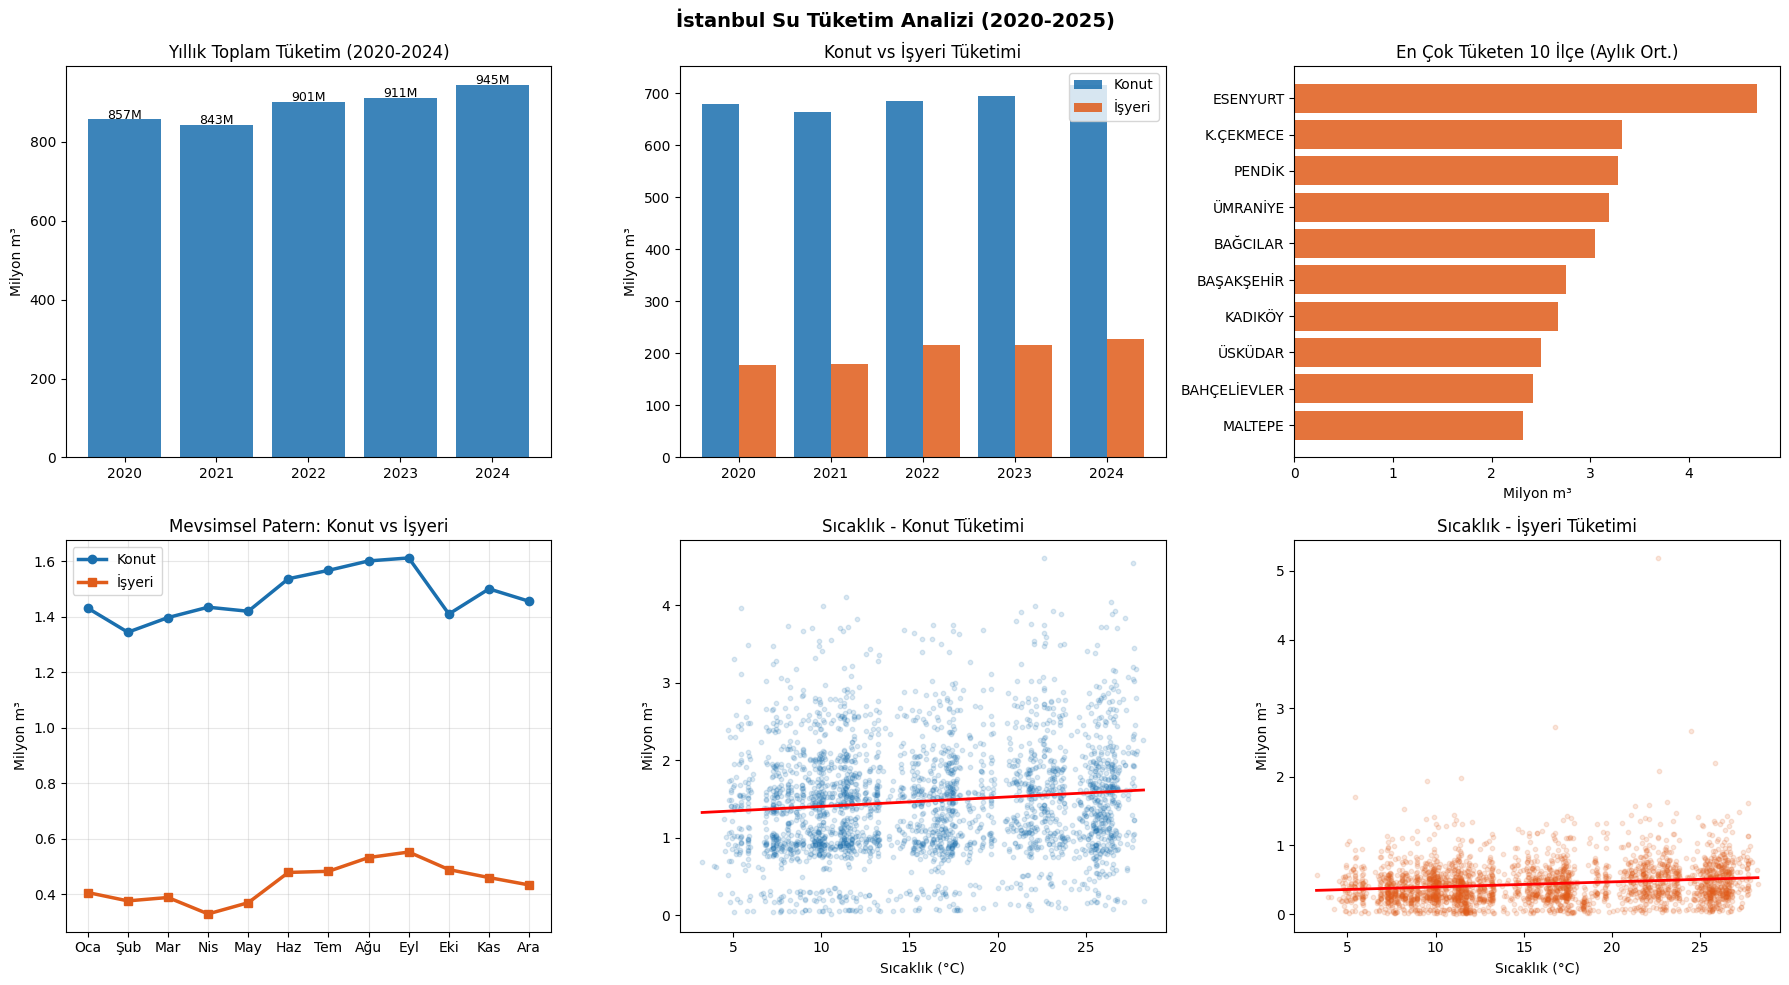

✅ Grafik kaydedildi: analiz.png


In [13]:
# ── AŞAMA 10: KEŞİFÇİ GRAFİKLER ───────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("İstanbul Su Tüketim Analizi (2020-2025)", fontsize=14, fontweight="bold")

ax1 = axes[0, 0]
yillik_tam = df[df["yil"] < 2025].groupby("yil")["su_tuketimi_m3"].sum() / 1e6
ax1.bar(yillik_tam.index, yillik_tam.values, color="#1a6fae", alpha=0.85)
ax1.set_title("Yıllık Toplam Tüketim (2020-2024)")
ax1.set_ylabel("Milyon m³")
ax1.set_xticks(yillik_tam.index)
for i, v in enumerate(yillik_tam.values):
    ax1.text(yillik_tam.index[i], v + 1, f"{v:.0f}M", ha="center", fontsize=9)

ax2 = axes[0, 1]
yillik_konut  = df[df["yil"] < 2025].groupby("yil")["konut_m3"].sum()  / 1e6
yillik_isyeri = df[df["yil"] < 2025].groupby("yil")["isyeri_m3"].sum() / 1e6
x = np.arange(len(yillik_konut))
ax2.bar(x - 0.2, yillik_konut.values,  width=0.4, label="Konut",  color="#1a6fae", alpha=0.85)
ax2.bar(x + 0.2, yillik_isyeri.values, width=0.4, label="İşyeri", color="#e05c1a", alpha=0.85)
ax2.set_title("Konut vs İşyeri Tüketimi")
ax2.set_ylabel("Milyon m³")
ax2.set_xticks(x)
ax2.set_xticklabels(yillik_konut.index)
ax2.legend()

ax3 = axes[0, 2]
top10 = ilce_ort.head(10) / 1e6
ax3.barh(top10.index[::-1], top10.values[::-1], color="#e05c1a", alpha=0.85)
ax3.set_title("En Çok Tüketen 10 İlçe (Aylık Ort.)")
ax3.set_xlabel("Milyon m³")

ax4 = axes[1, 0]
aylik_konut  = df.groupby("ay")["konut_m3"].mean()  / 1e6
aylik_isyeri = df.groupby("ay")["isyeri_m3"].mean() / 1e6
ay_isimleri  = ["Oca","Şub","Mar","Nis","May","Haz","Tem","Ağu","Eyl","Eki","Kas","Ara"]
ax4.plot(aylik_konut.index,  aylik_konut.values,  color="#1a6fae", linewidth=2.5, marker="o", label="Konut")
ax4.plot(aylik_isyeri.index, aylik_isyeri.values, color="#e05c1a", linewidth=2.5, marker="s", label="İşyeri")
ax4.set_title("Mevsimsel Patern: Konut vs İşyeri")
ax4.set_ylabel("Milyon m³")
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(ay_isimleri)
ax4.legend()
ax4.grid(True, alpha=0.3)

ax5 = axes[1, 1]
ax5.scatter(df["sicaklik_c"], df["konut_m3"] / 1e6, alpha=0.15, color="#1a6fae", s=10)
ax5.set_title("Sıcaklık - Konut Tüketimi")
ax5.set_xlabel("Sıcaklık (°C)")
ax5.set_ylabel("Milyon m³")
z = np.polyfit(df["sicaklik_c"], df["konut_m3"] / 1e6, 1)
ax5.plot(np.linspace(df["sicaklik_c"].min(), df["sicaklik_c"].max(), 100),
         np.poly1d(z)(np.linspace(df["sicaklik_c"].min(), df["sicaklik_c"].max(), 100)),
         color="red", linewidth=2)

ax6 = axes[1, 2]
ax6.scatter(df["sicaklik_c"], df["isyeri_m3"] / 1e6, alpha=0.15, color="#e05c1a", s=10)
ax6.set_title("Sıcaklık - İşyeri Tüketimi")
ax6.set_xlabel("Sıcaklık (°C)")
ax6.set_ylabel("Milyon m³")
z2 = np.polyfit(df["sicaklik_c"], df["isyeri_m3"] / 1e6, 1)
ax6.plot(np.linspace(df["sicaklik_c"].min(), df["sicaklik_c"].max(), 100),
         np.poly1d(z2)(np.linspace(df["sicaklik_c"].min(), df["sicaklik_c"].max(), 100)),
         color="red", linewidth=2)

plt.tight_layout()
plt.savefig("analiz.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grafik kaydedildi: analiz.png")

In [14]:
# ── AŞAMA 11: TİMESFM MODELİNİ YÜKLE ──────────────────────
# NOT: TimeGPT'den farklı olarak TimesFM tamamen lokaldir,
# API anahtarı gerekmez. İlk çalıştırmada Hugging Face'den
# ~1GB model ağırlıkları indirilir, sonraki çalıştırmalarda önbellekten yüklenir.

tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        backend="cpu",           # GPU varsa "gpu" yap → çok daha hızlı
        per_core_batch_size=32,
        horizon_len=12,          # Tahmin ufku: 12 ay (2025-01 → 2025-12)
    ),
    checkpoint=timesfm.TimesFmCheckpoint(
        huggingface_repo_id="google/timesfm-1.0-200m-pytorch"
    ),
)
print("✅ TimesFM modeli yüklendi")

Fetching 3 files: 100%|██████████| 3/3 [00:00<?, ?it/s]


✅ TimesFM modeli yüklendi


In [15]:
# ── AŞAMA 12: TİMESFM FORMATINA ÇEVİR ─────────────────────
# TimeGPT ile aynı strateji: konut ve işyerini AYRI AYRI tahmin et, sonra topla
# Bağlam: 2020-01 → 2024-12  |  Validasyon (gerçek): 2025-01 → 2025-10

def timesfm_hazirla(df, hedef_col, context_bitis="2024-12-01"):
    df_tgpt = df[["ilce", "tarih", hedef_col,
                  "sicaklik_c", "konut_abone", "isyeri_abone"]].copy()
    df_tgpt = df_tgpt.rename(columns={
        "ilce"    : "unique_id",
        "tarih"   : "ds",
        hedef_col : "y"
    })
    df_ctx = df_tgpt[df_tgpt["ds"] <= context_bitis].copy()
    df_val = df_tgpt[df_tgpt["ds"] >  context_bitis].copy()
    return df_ctx, df_val

df_ctx_konut,  df_val_konut  = timesfm_hazirla(df, "konut_m3")
df_ctx_isyeri, df_val_isyeri = timesfm_hazirla(df, "isyeri_m3")

print(f"✅ Konut   bağlam: {df_ctx_konut['ds'].min().strftime('%Y-%m')} → {df_ctx_konut['ds'].max().strftime('%Y-%m')}")
print(f"✅ İşyeri  bağlam: {df_ctx_isyeri['ds'].min().strftime('%Y-%m')} → {df_ctx_isyeri['ds'].max().strftime('%Y-%m')}")

✅ Konut   bağlam: 2020-01 → 2024-12
✅ İşyeri  bağlam: 2020-01 → 2024-12


In [16]:
# ── AŞAMA 13: EKSİK TARİHLERİ DOLDUR ──────────────────────
def tarihleri_tamamla(df_in, baslangic, bitis):
    tam_tarih = pd.date_range(start=baslangic, end=bitis, freq="MS")
    sonuc = []
    for ilce in df_in["unique_id"].unique():
        ilce_df = df_in[df_in["unique_id"] == ilce].set_index("ds")
        ilce_df = ilce_df.reindex(tam_tarih)
        ilce_df["unique_id"] = ilce
        ilce_df.index.name = "ds"
        ilce_df = ilce_df.reset_index()
        for col in ["y", "sicaklik_c", "konut_abone", "isyeri_abone"]:
            ilce_df[col] = ilce_df[col].interpolate(method="linear").ffill().bfill()
        sonuc.append(ilce_df)
    return pd.concat(sonuc).reset_index(drop=True)

# Bağlam: 2020-01 → 2024-12 (eğitim verisi)
df_ctx_konut_tam  = tarihleri_tamamla(df_ctx_konut,  "2020-01-01", "2024-12-01")
df_ctx_isyeri_tam = tarihleri_tamamla(df_ctx_isyeri, "2020-01-01", "2024-12-01")

# Validasyon: 2025-01 → 2025-10 (gerçek değerlerle karşılaştırılacak)
df_val_konut_tam  = tarihleri_tamamla(df_val_konut,  "2025-01-01", "2025-12-01")
df_val_isyeri_tam = tarihleri_tamamla(df_val_isyeri, "2025-01-01", "2025-12-01")

print(f"✅ Konut   bağlam (tam): {df_ctx_konut_tam.shape[0]} satır")
print(f"✅ İşyeri  bağlam (tam): {df_ctx_isyeri_tam.shape[0]} satır")
print(f"✅ Konut   validasyon  : {df_val_konut_tam.shape[0]} satır")
print(f"✅ İşyeri  validasyon  : {df_val_isyeri_tam.shape[0]} satır")

✅ Konut   bağlam (tam): 2340 satır
✅ İşyeri  bağlam (tam): 2340 satır
✅ Konut   validasyon  : 468 satır
✅ İşyeri  validasyon  : 468 satır


In [17]:
# ── AŞAMA 14: TİMESFM TAHMİN FONKSİYONU ───────────────────
# TimeGPT'den farklı olarak TimesFM exogenous (X_df) desteklemez.
# Sadece geçmiş seri kullanılır → daha sade ama API ücreti yok.
#
# freq parametresi:
#   0 = yüksek frekanslı (saatlik/günlük)
#   1 = düşük frekanslı  (haftalık/aylık) ← biz bunu kullanıyoruz

def timesfm_tahmin_yap(tfm, df_ctx, h=10, etiket=""):
    """
    tfm    : yüklü TimesFM modeli
    df_ctx : bağlam DataFrame'i (unique_id, ds, y sütunları olmalı)
    h      : tahmin ufku (ay sayısı)
    etiket : loglarda gösterilecek isim ("Konut" / "İşyeri")
    """
    sonuclar = []
    ilceler  = df_ctx["unique_id"].unique()

    print(f"⏳ {etiket} tahmini başlıyor — {len(ilceler)} ilçe...")

    for i, ilce in enumerate(ilceler):
        # İlçe serisini sırala ve listeye çevir
        seri = (
            df_ctx[df_ctx["unique_id"] == ilce]
            .sort_values("ds")["y"]
            .values
            .tolist()
        )

        # TimesFM tahmini — freq=1 → düşük frekanslı (aylık)
        nokta_tahmin, _ = tfm.forecast(
            inputs=[seri],
            freq=[1],
        )

        # Tahmin tarihlerini oluştur: bağlam bitişinden sonraki h ay
        son_tarih = (
            df_ctx[df_ctx["unique_id"] == ilce]["ds"].max()
        )
        tahmin_tarihleri = pd.date_range(
            start  = son_tarih + pd.DateOffset(months=1),
            periods= h,
            freq   = "MS"
        )

        # Negatif tahminleri sıfırla (tüketim negatif olamaz)
        tahmin_deger = np.maximum(nokta_tahmin[0][:h], 0)

        ilce_df = pd.DataFrame({
            "unique_id" : ilce,
            "ds"        : tahmin_tarihleri,
            "tahmin"    : tahmin_deger,
        })
        sonuclar.append(ilce_df)

        if (i + 1) % 10 == 0 or (i + 1) == len(ilceler):
            print(f"   {i+1}/{len(ilceler)} ilçe tamamlandı")

    return pd.concat(sonuclar).reset_index(drop=True)

print("✅ Tahmin fonksiyonu tanımlandı")

✅ Tahmin fonksiyonu tanımlandı


In [18]:
# ── AŞAMA 15: TİMESFM TAHMİNİ — KONUT ─────────────────────
tahmin_konut = timesfm_tahmin_yap(
    tfm    = tfm,
    df_ctx = df_ctx_konut_tam,
    h      = 12,
    etiket = "Konut"
)
tahmin_konut = tahmin_konut.rename(columns={"tahmin": "konut_tahmin"})
print(f"✅ Konut tahmini tamamlandı: {tahmin_konut.shape[0]} satır")

⏳ Konut tahmini başlıyor — 39 ilçe...
   10/39 ilçe tamamlandı
   20/39 ilçe tamamlandı
   30/39 ilçe tamamlandı
   39/39 ilçe tamamlandı
✅ Konut tahmini tamamlandı: 468 satır


In [19]:
# ── AŞAMA 16: TİMESFM TAHMİNİ — İŞYERİ ────────────────────
tahmin_isyeri = timesfm_tahmin_yap(
    tfm    = tfm,
    df_ctx = df_ctx_isyeri_tam,
    h      = 12,
    etiket = "İşyeri"
)
tahmin_isyeri = tahmin_isyeri.rename(columns={"tahmin": "isyeri_tahmin"})
print(f"✅ İşyeri tahmini tamamlandı: {tahmin_isyeri.shape[0]} satır")

⏳ İşyeri tahmini başlıyor — 39 ilçe...
   10/39 ilçe tamamlandı
   20/39 ilçe tamamlandı
   30/39 ilçe tamamlandı
   39/39 ilçe tamamlandı
✅ İşyeri tahmini tamamlandı: 468 satır


In [20]:
# ── AŞAMA 17: TAHMİNLERİ BİRLEŞTİR ────────────────────────
# Konut + işyeri tahminlerini topla → toplam tüketim tahmini
# NOT: TimesFM güven aralığı üretmediği için lo/hi sütunları yok

tahminler = tahmin_konut.merge(tahmin_isyeri, on=["unique_id", "ds"], how="inner")
tahminler["toplam_tahmin"] = tahminler["konut_tahmin"] + tahminler["isyeri_tahmin"]

print(f"✅ Tahminler birleştirildi: {tahminler.shape[0]} satır")
print(tahminler.head())

✅ Tahminler birleştirildi: 468 satır
  unique_id         ds  konut_tahmin  isyeri_tahmin  toplam_tahmin
0    ADALAR 2025-01-01  60804.007812   17975.373047   78779.382812
1    ADALAR 2025-02-01  57238.851562   15425.343750   72664.195312
2    ADALAR 2025-03-01  58710.207031   12717.721680   71427.929688
3    ADALAR 2025-04-01  60379.070312   12360.148438   72739.218750
4    ADALAR 2025-05-01  68837.507812   15016.631836   83854.140625


In [21]:
# ── AŞAMA 18: PERFORMANS DEĞERLENDİRMESİ ───────────────────
gercek = df_val_konut_tam[["unique_id", "ds", "y"]].rename(columns={"y": "konut_gercek"})
gercek = gercek.merge(
    df_val_isyeri_tam[["unique_id", "ds", "y"]].rename(columns={"y": "isyeri_gercek"}),
    on=["unique_id", "ds"]
)
gercek["toplam_gercek"] = gercek["konut_gercek"] + gercek["isyeri_gercek"]

karsilastirma = tahminler.merge(gercek, on=["unique_id", "ds"], how="inner")

def mape_hesapla(gercek, tahmin):
    return (gercek - tahmin).abs() / gercek.abs() * 100

karsilastirma["mape_konut"]  = mape_hesapla(karsilastirma["konut_gercek"],  karsilastirma["konut_tahmin"])
karsilastirma["mape_isyeri"] = mape_hesapla(karsilastirma["isyeri_gercek"], karsilastirma["isyeri_tahmin"])
karsilastirma["mape_toplam"] = mape_hesapla(karsilastirma["toplam_gercek"], karsilastirma["toplam_tahmin"])

karsilastirma["abs_konut"]  = (karsilastirma["konut_gercek"]  - karsilastirma["konut_tahmin"]).abs()
karsilastirma["abs_isyeri"] = (karsilastirma["isyeri_gercek"] - karsilastirma["isyeri_tahmin"]).abs()
karsilastirma["abs_toplam"] = (karsilastirma["toplam_gercek"] - karsilastirma["toplam_tahmin"]).abs()

metrikler = (
    karsilastirma
    .groupby("unique_id")
    .agg(
        MAPE_Konut   = ("mape_konut",  "mean"),
        MAPE_Isyeri  = ("mape_isyeri", "mean"),
        MAPE_Toplam  = ("mape_toplam", "mean"),
        MAE_Konut    = ("abs_konut",   "mean"),
        MAE_Isyeri   = ("abs_isyeri",  "mean"),
        MAE_Toplam   = ("abs_toplam",  "mean"),
        RMSE_Konut   = ("abs_konut",   lambda x: np.sqrt((x**2).mean())),
        RMSE_Isyeri  = ("abs_isyeri",  lambda x: np.sqrt((x**2).mean())),
        RMSE_Toplam  = ("abs_toplam",  lambda x: np.sqrt((x**2).mean())),
    )
    .reset_index()
    .sort_values("MAPE_Toplam")
)

print("\n📊 İLÇE BAZLI PERFORMANS:")
print(metrikler.to_string(index=False))
print(f"\n🎯 Ort. MAPE  Konut  : {metrikler['MAPE_Konut'].mean():.2f}%")
print(f"🎯 Ort. MAPE  İşyeri : {metrikler['MAPE_Isyeri'].mean():.2f}%")
print(f"🎯 Ort. MAPE  Toplam : {metrikler['MAPE_Toplam'].mean():.2f}%")
print(f"🎯 Ort. MAE   Toplam : {metrikler['MAE_Toplam'].mean():,.0f} m³")
print(f"🎯 Ort. RMSE  Toplam : {metrikler['RMSE_Toplam'].mean():,.0f} m³")


📊 İLÇE BAZLI PERFORMANS:
   unique_id  MAPE_Konut  MAPE_Isyeri  MAPE_Toplam     MAE_Konut    MAE_Isyeri    MAE_Toplam    RMSE_Konut   RMSE_Isyeri   RMSE_Toplam
  BAYRAMPAŞA    6.481744     9.909070     6.233303  47354.840625  33488.326562  71162.883333  87126.026048  54494.712842  99690.190044
BAHÇELİEVLER    7.607527    10.342036     6.809830 126696.377083  44846.993750 138414.566667 202188.706100  63104.892582 245178.475125
    ESENYURT    7.541551     6.921971     6.832938 225675.679167  86066.858333 291931.641667 394319.026324 106638.998961 474867.252830
    G.O.PAŞA    6.711062    11.768239     6.957420  81415.025000  24923.680729  98766.266667 174811.597923  33763.473219 201001.714012
     BEYOĞLU    7.803895     9.496803     7.152973  53040.611458  59276.894792  94315.204167  85556.755830 106351.234689 150442.793085
       ŞİŞLİ    9.102416     6.594750     7.251961  81901.075000  43446.896875 117734.872917 122968.216231  52190.401804 148162.171947
     MALTEPE    6.681312    1

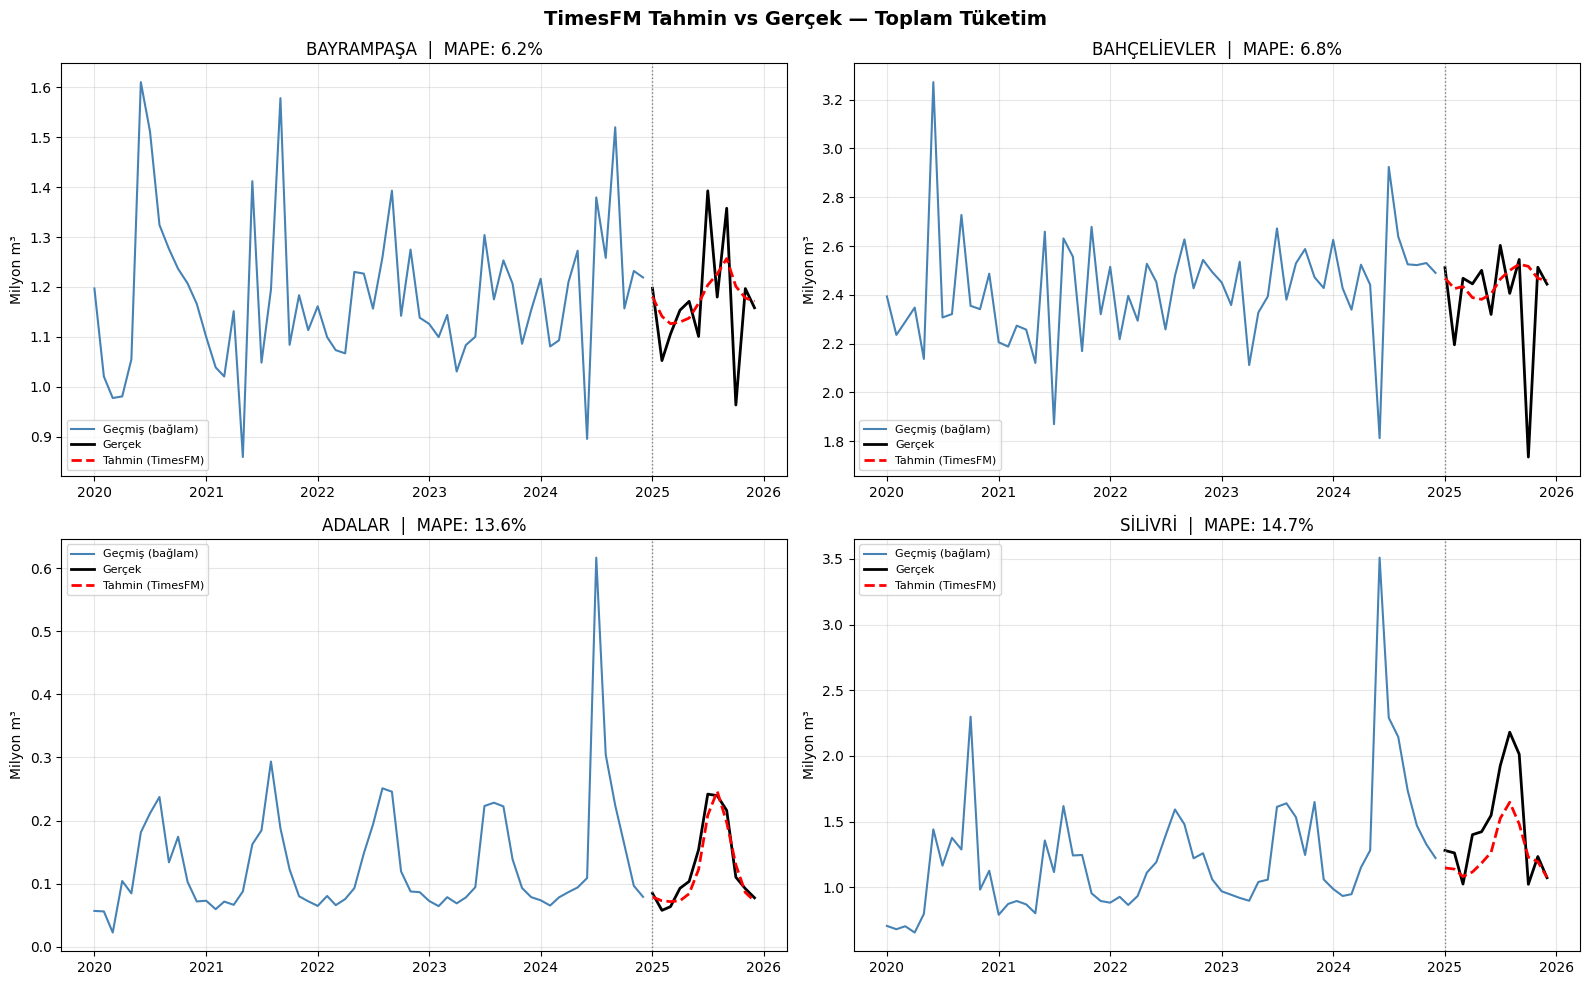

✅ Tahmin grafikleri kaydedildi: tahmin_grafikleri_timesfm.png


In [22]:
# ── AŞAMA 19: TAHMİN GRAFİKLERİ ────────────────────────────
# NOT: TimesFM güven aralığı üretmediğinden fill_between kaldırıldı

en_iyi  = metrikler.head(2)["unique_id"].tolist()
en_kotu = metrikler.tail(2)["unique_id"].tolist()
gosterilecek = en_iyi + en_kotu

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("TimesFM Tahmin vs Gerçek — Toplam Tüketim", fontsize=14, fontweight="bold")

for ax, ilce in zip(axes.flatten(), gosterilecek):
    gecmis       = df_ctx_konut_tam[df_ctx_konut_tam["unique_id"] == ilce].copy()
    gecmis_isyeri= df_ctx_isyeri_tam[df_ctx_isyeri_tam["unique_id"] == ilce].copy()
    gecmis["toplam"] = gecmis["y"].values + gecmis_isyeri["y"].values

    k        = karsilastirma[karsilastirma["unique_id"] == ilce]
    mape_val = metrikler[metrikler["unique_id"] == ilce]["MAPE_Toplam"].values[0]

    ax.plot(gecmis["ds"], gecmis["toplam"] / 1e6,
            color="steelblue", linewidth=1.5, label="Geçmiş (bağlam)")
    ax.plot(k["ds"], k["toplam_gercek"] / 1e6,
            color="black", linewidth=2, label="Gerçek")
    ax.plot(k["ds"], k["toplam_tahmin"] / 1e6,
            color="red", linewidth=2, linestyle="--", label="Tahmin (TimesFM)")
    # Güven aralığı yok — TimesFM nokta tahmini üretir
    ax.axvline(pd.Timestamp("2025-01-01"), color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"{ilce}  |  MAPE: {mape_val:.1f}%")
    ax.set_ylabel("Milyon m³")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("tahmin_grafikleri_timesfm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Tahmin grafikleri kaydedildi: tahmin_grafikleri_timesfm.png")

In [23]:
# ── AŞAMA 20: SONUÇLARI EXCEL'E KAYDET ─────────────────────
CIKTI_DOSYASI = r"C:\Users\mynet\OneDrive\Masaüstü\istanbul_su_tahmini_timesfm.xlsx"

with pd.ExcelWriter(CIKTI_DOSYASI, engine="openpyxl") as writer:
    karsilastirma.to_excel(writer, sheet_name="Tahmin vs Gerçek",   index=False)
    metrikler.to_excel(    writer, sheet_name="Performans",          index=False)
    tahminler.to_excel(    writer, sheet_name="Tahminler",           index=False)
    df_ctx_konut_tam.to_excel( writer, sheet_name="Bağlam Konut",   index=False)
    df_ctx_isyeri_tam.to_excel(writer, sheet_name="Bağlam İşyeri",  index=False)
    df.to_excel(           writer, sheet_name="Ham Veri",            index=False)

print(f"✅ Excel kaydedildi: {CIKTI_DOSYASI}")
print("\n🎉 Tüm işlem tamamlandı! (TimesFM)")

✅ Excel kaydedildi: C:\Users\mynet\OneDrive\Masaüstü\istanbul_su_tahmini_timesfm.xlsx

🎉 Tüm işlem tamamlandı! (TimesFM)
